<a href="https://colab.research.google.com/github/AngeloSorte/AI-Climate-Intelligence-GDP-vs-CO-Decoupling-Analysis/blob/angelosorte.github.io/Global_Carbon_Intelligence_System_(GCIS)_Decoupling%2C_Prediction_%26_Climate_Clustering_(Real_World_Data_2000%E2%80%932025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (650, 4)

🌍 DECOUPLING SCORE:
country
USA    0.984375
CAN    0.781250
DEU    0.750000
CHN    0.734375
ITA    0.718750
FRA    0.687500
BRA    0.671875
JPN    0.656250
IND    0.625000
ZAF    0.578125
Name: decoupling, dtype: float64

📊 R2: 0.9196651216419258

🌍 CLUSTERS:
                  gdp          co2  cluster
country                                    
BRA      7.945766e+11   274.221422        0
CAN      7.908394e+11   459.231172        0
CHN      3.645293e+12  4368.521281        2
DEU      1.955340e+12   920.046734        0
FRA      1.377322e+12   400.819828        0
IND      8.469142e+11   988.148875        0
ITA      1.097329e+12   368.114312        0
JPN      3.001329e+12   997.730609        0
USA      8.954602e+12  4930.166156        1
ZAF      1.757774e+11   320.390500        0


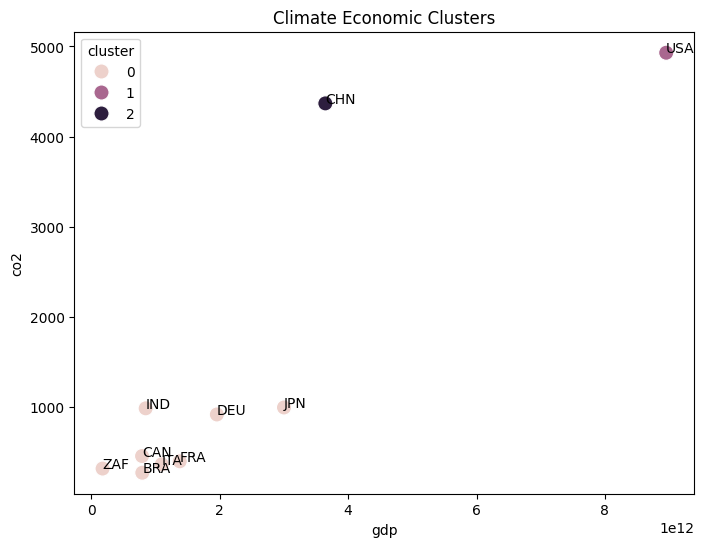


🏁 TOP DECOUPLING COUNTRIES:
country
USA    0.984375
CAN    0.781250
DEU    0.750000
CHN    0.734375
ITA    0.718750
Name: decoupling, dtype: float64


In [7]:
# =========================================
# 🌍 GLOBAL CARBON INTELLIGENCE SYSTEM
# FINAL CLEAN VERSION
# =========================================

!pip install pandas numpy matplotlib seaborn scikit-learn requests --quiet

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score

# =========================================
# 1. COUNTRIES (ISO CLEAN)
# =========================================

countries = ["USA","CHN","IND","DEU","ITA","FRA","BRA","ZAF","JPN","CAN"]

# =========================================
# 2. GDP (WORLD BANK SAFE API)
# =========================================

def load_gdp(country):
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/NY.GDP.MKTP.CD?format=json&per_page=20000"

    r = requests.get(url, timeout=10)
    js = r.json()

    if not isinstance(js, list) or len(js) < 2:
        return pd.DataFrame()

    data = js[1]

    rows = []
    for d in data:
        if d["value"] is not None:
            rows.append({
                "country": country,
                "year": int(d["date"]),
                "gdp": float(d["value"])
            })

    return pd.DataFrame(rows)

gdp = pd.concat([load_gdp(c) for c in countries], ignore_index=True)

# FORCE CLEAN
gdp = gdp.dropna()
gdp = gdp.drop_duplicates()
gdp = gdp[["country","year","gdp"]]

# =========================================
# 3. CO2 (OWID CLEAN)
# =========================================

co2 = pd.read_csv(
    "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
)

# IMPORTANT FIX: ONLY REQUIRED COLUMNS
co2 = co2[["iso_code","year","co2"]].dropna()

co2 = co2.rename(columns={"iso_code":"country"})

co2 = co2[co2["country"].isin(countries)]

co2 = co2.drop_duplicates()
co2 = co2[["country","year","co2"]]

# =========================================
# 4. MERGE SAFE
# =========================================

df = pd.merge(
    gdp,
    co2,
    on=["country","year"],
    how="inner"
)

df = df.dropna()
df = df.sort_values(["country","year"])

print("Dataset shape:", df.shape)

# =========================================
# 5. DECOUPLING ENGINE
# =========================================

df["gdp_growth"] = df.groupby("country")["gdp"].pct_change()
df["co2_growth"] = df.groupby("country")["co2"].pct_change()

df = df.dropna()

df["decoupling"] = df["gdp_growth"] > df["co2_growth"]

score = df.groupby("country")["decoupling"].mean().sort_values(ascending=False)

print("\n🌍 DECOUPLING SCORE:")
print(score)

# =========================================
# 6. ML MODEL
# =========================================

X = df[["gdp"]].values
y = df["co2"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_scaled, y)

df["pred"] = model.predict(X_scaled)

print("\n📊 R2:", r2_score(y, df["pred"]))

# =========================================
# 7. CLUSTERING
# =========================================

cluster_data = df.groupby("country")[["gdp","co2"]].mean()

Xc = StandardScaler().fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data["cluster"] = kmeans.fit_predict(Xc)

print("\n🌍 CLUSTERS:")
print(cluster_data)

# =========================================
# 8. VISUALIZATION
# =========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_data["gdp"],
    y=cluster_data["co2"],
    hue=cluster_data["cluster"],
    s=120
)

for i in cluster_data.index:
    plt.text(
        cluster_data.loc[i,"gdp"],
        cluster_data.loc[i,"co2"],
        i
    )

plt.title("Climate Economic Clusters")
plt.show()

# =========================================
# FINAL OUTPUT
# =========================================

print("\n🏁 TOP DECOUPLING COUNTRIES:")
print(score.head(5))